# Projeto Avaliativo - Camada Gold

Este notebook responde às perguntas de negócio com SQL, JOINs, GROUP BY, tabelas e gráficos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text
from banco import criar_engine, testar_conexao

pd.set_option('display.float_format', '{:,.2f}'.format)

testar_conexao()
engine = criar_engine()

Conexão com PostgreSQL realizada com sucesso.


## 1. Os 5 órgãos com maior custo total

In [2]:
sql_1 = '''SELECT nome_orgao_superior, SUM(valor_total) AS custo_total FROM silver_viagem GROUP BY nome_orgao_superior ORDER BY custo_total DESC LIMIT 5;'''
df_1 = pd.read_sql(sql_1, engine)
df_1

,nome_orgao_superior,custo_total
0,Ministério da Justiça e Segurança Pública,"486,933,121.65"
1,Ministério da Defesa,"156,070,304.49"
2,Ministério da Educação,"111,291,402.82"
3,Ministério do Meio Ambiente e Mudança do Clima,"49,697,710.16"
4,Ministério da Previdência Social,"40,417,309.06"


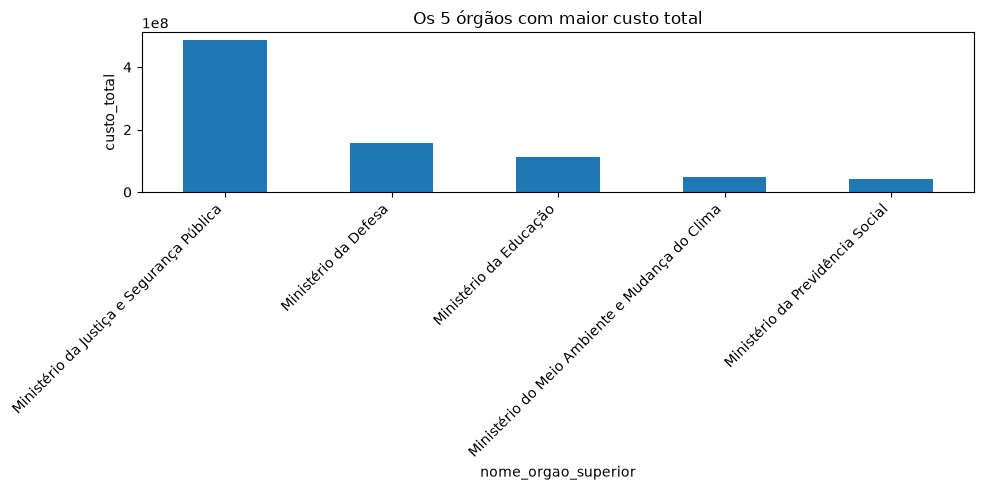

In [3]:
ax = df_1.plot(kind='bar', x='nome_orgao_superior', y='custo_total', legend=False, figsize=(10,5))
ax.set_title('Os 5 órgãos com maior custo total')
ax.set_xlabel('nome_orgao_superior')
ax.set_ylabel('custo_total')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Os 3 destinos com maior custo médio por viagem

In [4]:
sql_2 = '''SELECT t.destino_uf, t.destino_cidade, AVG(v.valor_total) AS custo_medio_viagem, COUNT(DISTINCT v.id_viagem) AS quantidade_viagens FROM silver_viagem v JOIN silver_trecho t ON v.id_viagem = t.id_viagem WHERE t.destino_cidade IS NOT NULL GROUP BY t.destino_uf, t.destino_cidade HAVING COUNT(DISTINCT v.id_viagem) >= 3 ORDER BY custo_medio_viagem DESC LIMIT 3;'''
df_2 = pd.read_sql(sql_2, engine)
df_2

,destino_uf,destino_cidade,custo_medio_viagem,quantidade_viagens
0,Rondônia,Monte Negro,"96,133.26",98
1,Rio Grande do Sul,Sananduva,"95,397.81",103
2,Rio Grande do Sul,Nonoai,"91,901.19",117


## 3. A viagem de maior duração e seu custo total

In [5]:
sql_3 = '''SELECT id_viagem, num_proposta, nome_orgao_superior, destinos, duracao_dias, valor_total FROM silver_viagem ORDER BY duracao_dias DESC, valor_total DESC LIMIT 1;'''
df_3 = pd.read_sql(sql_3, engine)
df_3

,id_viagem,num_proposta,nome_orgao_superior,destinos,duracao_dias,valor_total
0,0000000000020699856,000428/25-4C,Ministério da Previdência Social,Mogi Mirim/SP,383,0.00


## 4. Tipo de pagamento com maior valor médio

In [6]:
sql_4 = '''SELECT tipo_pagamento, AVG(valor) AS valor_medio, COUNT(*) AS quantidade_pagamentos FROM silver_pagamento GROUP BY tipo_pagamento ORDER BY valor_medio DESC LIMIT 1;'''
df_4 = pd.read_sql(sql_4, engine)
df_4

,tipo_pagamento,valor_medio,quantidade_pagamentos
0,PASSAGEM,"1,856.78",186008


## 5. Meio de transporte mais usado nos trechos

In [7]:
sql_5 = '''SELECT meio_transporte, COUNT(*) AS quantidade_trechos FROM silver_trecho WHERE meio_transporte IS NOT NULL GROUP BY meio_transporte ORDER BY quantidade_trechos DESC LIMIT 5;'''
df_5 = pd.read_sql(sql_5, engine)
df_5

,meio_transporte,quantidade_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659


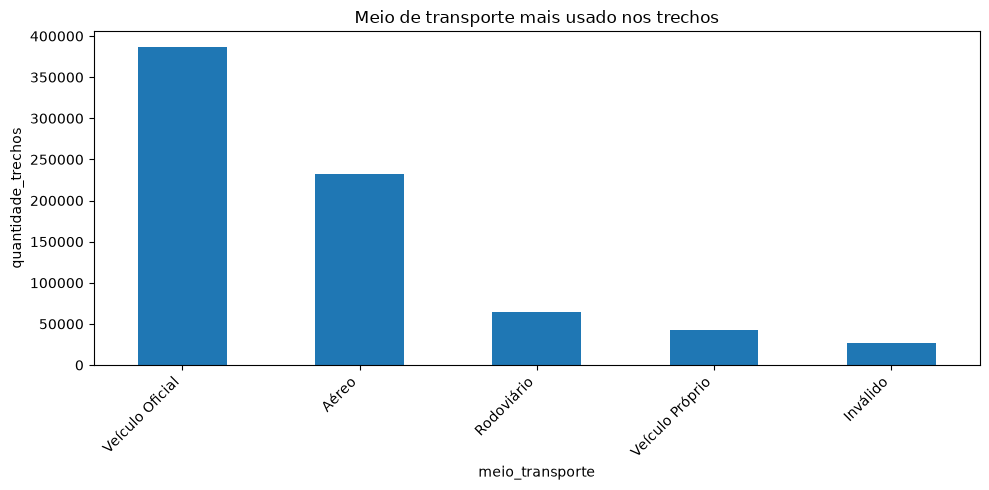

In [8]:
ax = df_5.plot(kind='bar', x='meio_transporte', y='quantidade_trechos', legend=False, figsize=(10,5))
ax.set_title('Meio de transporte mais usado nos trechos')
ax.set_xlabel('meio_transporte')
ax.set_ylabel('quantidade_trechos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. UF de destino que aparece em mais trechos

In [9]:
sql_6 = '''SELECT destino_uf, COUNT(*) AS quantidade_trechos FROM silver_trecho WHERE destino_uf IS NOT NULL GROUP BY destino_uf ORDER BY quantidade_trechos DESC LIMIT 10;'''
df_6 = pd.read_sql(sql_6, engine)
df_6

,destino_uf,quantidade_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


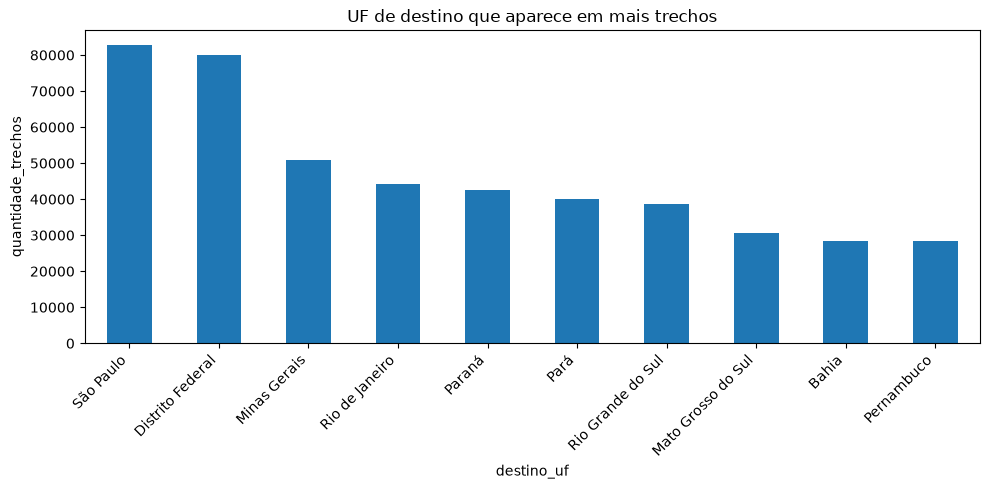

In [10]:
ax = df_6.plot(kind='bar', x='destino_uf', y='quantidade_trechos', legend=False, figsize=(10,5))
ax.set_title('UF de destino que aparece em mais trechos')
ax.set_xlabel('destino_uf')
ax.set_ylabel('quantidade_trechos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Órgão que pagou mais no total

In [11]:
sql_7 = '''SELECT nome_orgao_pagador, SUM(valor) AS total_pago FROM silver_pagamento WHERE nome_orgao_pagador IS NOT NULL GROUP BY nome_orgao_pagador ORDER BY total_pago DESC LIMIT 5;'''
df_7 = pd.read_sql(sql_7, engine)
df_7

,nome_orgao_pagador,total_pago
0,Sigiloso,"170,659,883.35"
1,Fundo Nacional de Segurança Pública,"141,911,719.64"
2,Comando da Aeronáutica,"81,180,823.06"
3,Comando do Exército,"35,901,379.45"
4,Instituto Nacional do Seguro Social,"35,385,354.57"


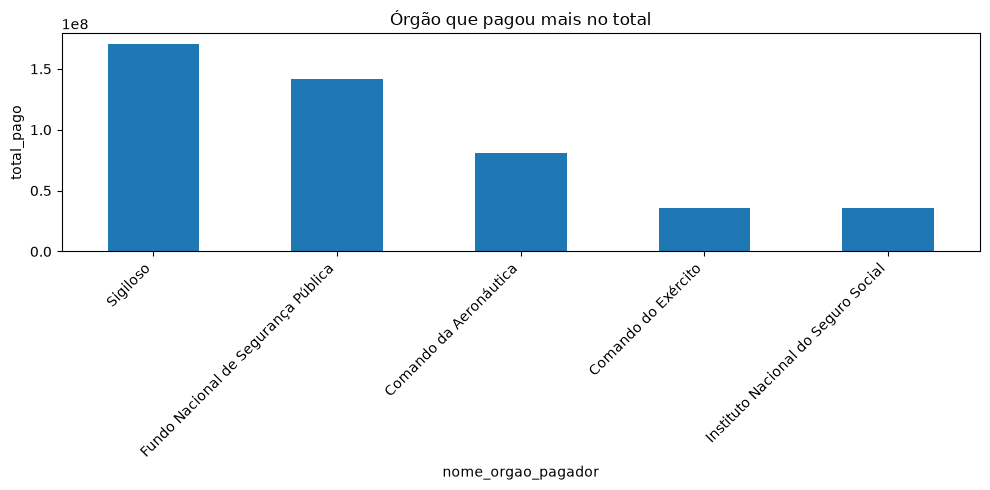

In [12]:
ax = df_7.plot(kind='bar', x='nome_orgao_pagador', y='total_pago', legend=False, figsize=(10,5))
ax.set_title('Órgão que pagou mais no total')
ax.set_xlabel('nome_orgao_pagador')
ax.set_ylabel('total_pago')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Criação das tabelas Gold

In [13]:
with open('3_gold_consultas.sql', 'r', encoding='utf-8') as f:
    sql_gold = f.read()

with engine.begin() as conn:
    conn.execute(text(sql_gold))

print('Consultas e tabelas Gold executadas com sucesso.')

Consultas e tabelas Gold executadas com sucesso.
